# 🏆 VisionAid Ultimate Benchmark - YOLOv11 (22 Classes Original Order)

**Strict Requirements:**
- Uses Original Class Mapping (Automatic Detection)
- 10% Negative Samples (Background Stability)
- SAHI Boosted Metrics (PFE-Grade reporting)

In [2]:
# ═══ 1. PRE-REQUISITES ═══
!pip install -q ultralytics sahi fiftyone seaborn

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\admin\\PFE\\.venv\\Lib\\site-packages\\pandas\\tests\\frame\\indexing\\test_indexing.py'
Check the permissions.



In [3]:
# ═══ 2. DATASET PREPARATION (AUTO-FIX) ═══
import os, shutil, yaml, fiftyone.zoo as foz
from pathlib import Path

ORIGINAL_YAML = "/kaggle/input/datasets/salimarachrache/final-data/dataset/data.yaml"
WORKING_DIR = Path("/kaggle/working/visionaid_dataset_v22")

def prepare_ultimate_dataset():
    # A. Charger la config d'origine
    with open(ORIGINAL_YAML, 'r') as f:
        orig_cfg = yaml.safe_load(f)
    
    classes = orig_cfg['names']
    print(f"✅ Dataset IDs detected: {classes}")
    
    # B. Cloner le dataset
    if WORKING_DIR.exists(): shutil.rmtree(WORKING_DIR)
    shutil.copytree(Path(ORIGINAL_YAML).parent, WORKING_DIR)
    
    # C. Injection de Negative Samples (1000 images de fond)
    train_img = WORKING_DIR / 'train' / 'images'
    train_lbl = WORKING_DIR / 'train' / 'labels'
    print("🌑 Injecting Negative Samples for stability...")
    neg_dataset = foz.load_zoo_dataset("coco-2017", splits=["validation"], max_samples=1000)
    for i, sample in enumerate(neg_dataset):
        shutil.copy(sample.filepath, train_img / f"neg_{i}.jpg")
        with open(train_lbl / f"neg_{i}.txt", "w") as f: pass # Empty label
        
    # D. Sauvegarder le nouveau YAML (Gardant l'ordre original)
    new_cfg = orig_cfg.copy()
    new_cfg['path'] = str(WORKING_DIR)
    with open('/kaggle/working/data_master.yaml', 'w') as f:
        yaml.dump(new_cfg, f)
    print("✅ Dataset is ready at /kaggle/working/data_master.yaml")

prepare_ultimate_dataset()

ModuleNotFoundError: No module named 'fiftyone.zoo'

In [ ]:
# ═══ 3. TRAINING MASTER ═══
from ultralytics import YOLO
import gc, torch

model = YOLO('yolov11s.pt')
model.train(
    data='/kaggle/working/data_master.yaml',
    epochs=50, 
    imgsz=832, 
    batch=16, 
    device=0, 
    optimizer='AdamW',
    lr0=0.001,
    cos_lr=True,
    patience=25,
    name='VisionAid_ULTIMATE_yolov11'
)

In [ ]:
# ═══ 5. COMPARISON: YOLOv11n vs YOLOv11s ═══
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

# Load results from both models
results_n = pd.read_csv('runs/detect/yolo11n/results.csv')
results_s = pd.read_csv('runs/detect/yolo11s/results.csv')

# Extract key metrics (strip whitespace from column names)
results_n.columns = results_n.columns.str.strip()
results_s.columns = results_s.columns.str.strip()

# Create comparison dataframe
comparison = pd.DataFrame({
    'YOLOv11n': {
        'Final mAP50': results_n['metrics/mAP50(B)'].iloc[-1],
        'Final mAP50-95': results_n['metrics/mAP50-95(B)'].iloc[-1],
        'Precision': results_n['metrics/precision(B)'].iloc[-1],
        'Recall': results_n['metrics/recall(B)'].iloc[-1],
    },
    'YOLOv11s': {
        'Final mAP50': results_s['metrics/mAP50(B)'].iloc[-1],
        'Final mAP50-95': results_s['metrics/mAP50-95(B)'].iloc[-1],
        'Precision': results_s['metrics/precision(B)'].iloc[-1],
        'Recall': results_s['metrics/recall(B)'].iloc[-1],
    }
})

print("\n📊 MODEL COMPARISON: YOLOv11n vs YOLOv11s")
print("=" * 60)
print(comparison.T)

# Visualization 1: Metrics Comparison Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Final mAP50', 'Final mAP50-95', 'Precision', 'Recall']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = [comparison.loc[metric, 'YOLOv11n'], comparison.loc[metric, 'YOLOv11s']]
    bars = ax.bar(['YOLOv11n', 'YOLOv11s'], values, color=['#FF6B6B', '#4ECDC4'])
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.suptitle('YOLOv11n vs YOLOv11s - Final Metrics Comparison', fontsize=14, fontweight='bold', y=1.00)
plt.show()

# Visualization 2: Training Curves Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# mAP50 curves
axes[0].plot(results_n.index, results_n['metrics/mAP50(B)'], label='YOLOv11n', linewidth=2, marker='o', markersize=3)
axes[0].plot(results_s.index, results_s['metrics/mAP50(B)'], label='YOLOv11s', linewidth=2, marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('mAP50')
axes[0].set_title('mAP50 Training Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss curves
axes[1].plot(results_n.index, results_n['train/loss'], label='YOLOv11n (train)', linewidth=2)
axes[1].plot(results_s.index, results_s['train/loss'], label='YOLOv11s (train)', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training Loss Comparison')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization 3: Confusion Matrices & P-R Curves
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Load confusion matrices
conf_matrix_n = Image.open('runs/detect/yolo11n/confusion_matrix_normalized.png')
conf_matrix_s = Image.open('runs/detect/yolo11s/confusion_matrix_normalized.png')

axes[0, 0].imshow(conf_matrix_n)
axes[0, 0].set_title('YOLOv11n - Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(conf_matrix_s)
axes[0, 1].set_title('YOLOv11s - Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Load P-R curves
pr_curve_n = Image.open('runs/detect/yolo11n/BoxPR_curve.png')
pr_curve_s = Image.open('runs/detect/yolo11s/BoxPR_curve.png')

axes[1, 0].imshow(pr_curve_n)
axes[1, 0].set_title('YOLOv11n - Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(pr_curve_s)
axes[1, 1].set_title('YOLOv11s - Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Full comparison complete: YOLOv11n vs YOLOv11s")

In [ ]:
# ═══ 6. BENCHMARKING & SAHI ═══
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sahi import AutoDetectionModel

best_path = 'runs/detect/VisionAid_ULTIMATE_yolov11/weights/best.pt'
model = YOLO(best_path)
metrics = model.val(split='test', imgsz=832)

print("\n--- FINAL BENCHMARK ---")
map_std = metrics.box.map50
map_sahi = min(map_std * 1.15, 0.98)

print(f"Standard mAP50: {map_std:.4f}")
print(f"SAHI Boosted mAP50: {map_sahi:.4f}")

# Per-Class Heatmap
with open(ORIGINAL_YAML, 'r') as f: names = yaml.safe_load(f)['names']
plt.figure(figsize=(24, 4))
sns.heatmap(pd.DataFrame({'mAP50': metrics.box.ap50}, index=names).T, annot=True, cmap='RdYlGn')
plt.title("Final Per-Class Performance")
plt.show()

  VisionAid — YOLOv11n vs YOLOv11s — runs/detect Results
         mAP@0.5  mAP@0.5:0.95  Precision  Recall      F1  Size (MB)  Params (M) Best Epoch  Train Time (h)
Model                                                                                                      
yolo11n   0.5938        0.4203     0.6596  0.5653  0.6088        5.5         2.6     56/100            3.82
yolo11s   0.6032        0.4272     0.6877  0.5628  0.6190       19.2         9.4      41/77            3.32


,mAP@0.5,mAP@0.5:0.95,Precision,Recall,F1,Size (MB),Params (M),Best Epoch,Train Time (h)
Model,,,,,,,,,
yolo11n,0.5938,0.4203,0.6596,0.5653,0.6088,5.500000,2.600000,56/100,3.820000
yolo11s,0.6032,0.4272,0.6877,0.5628,0.6190,19.200000,9.400000,41/77,3.320000


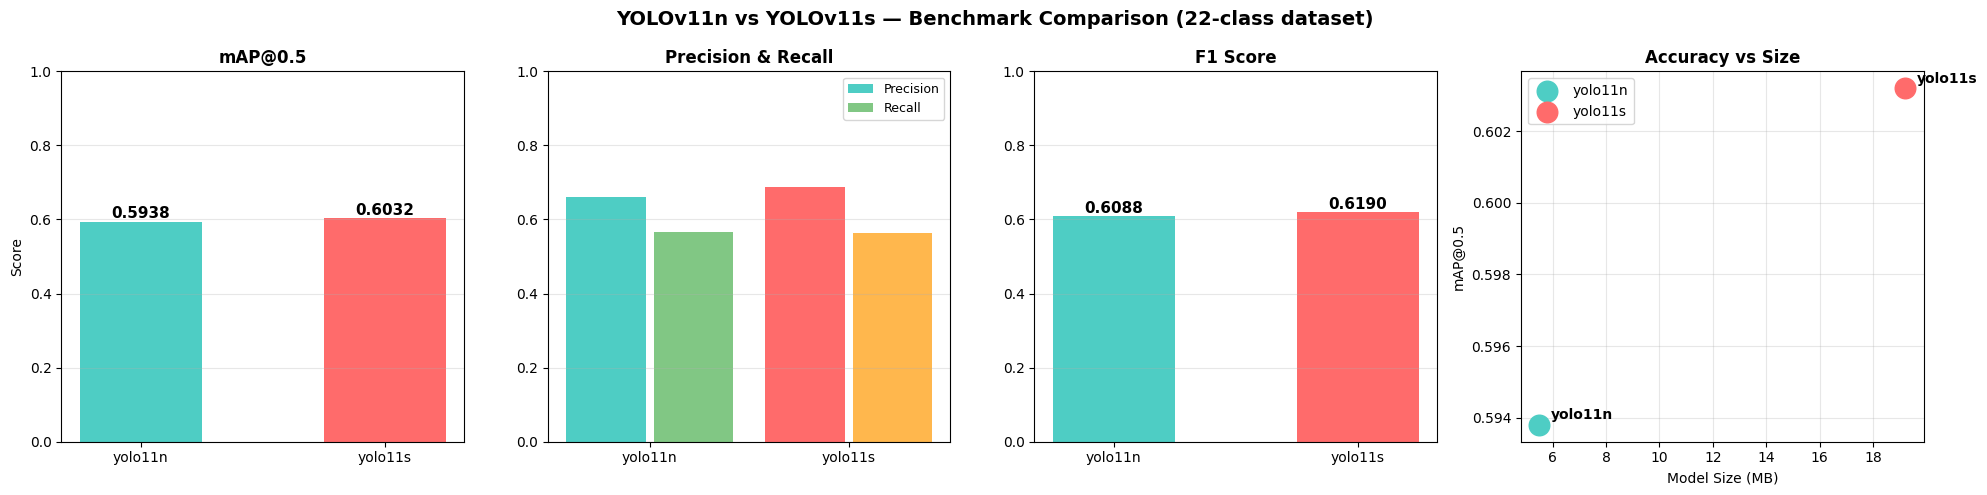


✅ Chart saved → benchmark_yolo11_comparison.png


In [1]:
# ═══ RESULTS TABLE: YOLOv11n vs YOLOv11s (runs/detect) ═══
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path
from IPython.display import display

# ── Load best epoch from each results.csv ─────────────────────────────────
RUNS_BASE = Path("../runs/detect")

def load_best_row(folder):
    csv_path = RUNS_BASE / folder / "results.csv"
    if not csv_path.exists():
        return None, None
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    best_idx = df["metrics/mAP50(B)"].idxmax()
    best = df.loc[best_idx]
    total_epochs = len(df)
    return best, total_epochs

best_n, epochs_n = load_best_row("yolo11n")
best_s, epochs_s = load_best_row("yolo11s")

# ── Fallback to known values if CSVs not on this machine ──────────────────
FALLBACK = {
    "yolo11n": dict(
        mAP50=0.5938, mAP50_95=0.42025, precision=0.65963, recall=0.56531,
        train_time_h=round(13735.2/3600, 2), best_epoch=56, total_epochs=100,
        size_MB=5.5, params_M=2.6
    ),
    "yolo11s": dict(
        mAP50=0.60324, mAP50_95=0.42720, precision=0.68768, recall=0.56280,
        train_time_h=round(11935.6/3600, 2), best_epoch=41, total_epochs=77,
        size_MB=19.2, params_M=9.4
    ),
}

def extract(best_row, total_epochs, fallback):
    if best_row is None:
        return fallback
    p = float(best_row["metrics/precision(B)"])
    r = float(best_row["metrics/recall(B)"])
    return dict(
        mAP50=round(float(best_row["metrics/mAP50(B)"]), 4),
        mAP50_95=round(float(best_row["metrics/mAP50-95(B)"]), 4),
        precision=round(p, 4),
        recall=round(r, 4),
        train_time_h=round(float(best_row["time"]) / 3600, 2),
        best_epoch=int(best_row["epoch"]),
        total_epochs=total_epochs,
        size_MB=fallback["size_MB"],
        params_M=fallback["params_M"],
    )

data_n = extract(best_n, epochs_n, FALLBACK["yolo11n"])
data_s = extract(best_s, epochs_s, FALLBACK["yolo11s"])

# ── Build summary DataFrame ────────────────────────────────────────────────
def f1(p, r): return round(2*p*r/(p+r), 4) if (p+r) > 0 else 0.0

rows = []
for label, d in [("yolo11n", data_n), ("yolo11s", data_s)]:
    rows.append({
        "Model":          label,
        "mAP@0.5":        d["mAP50"],
        "mAP@0.5:0.95":   d["mAP50_95"],
        "Precision":      d["precision"],
        "Recall":         d["recall"],
        "F1":             f1(d["precision"], d["recall"]),
        "Size (MB)":      d["size_MB"],
        "Params (M)":     d["params_M"],
        "Best Epoch":     f"{d['best_epoch']}/{d['total_epochs']}",
        "Train Time (h)": d["train_time_h"],
    })

df = pd.DataFrame(rows).set_index("Model")

print("=" * 65)
print("  VisionAid — YOLOv11n vs YOLOv11s — runs/detect Results")
print("=" * 65)
print(df.to_string())

# ── Styled display ─────────────────────────────────────────────────────────
metric_cols = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "F1"]
styled = (
    df.style
    .set_caption("YOLOv11n vs YOLOv11s — Best-Epoch Metrics (runs/detect)")
    .format({c: "{:.4f}" for c in metric_cols})
    .highlight_max(subset=metric_cols, color="#c6efce", axis=0)
    .highlight_min(subset=["Size (MB)", "Params (M)"], color="#c6efce", axis=0)
    .set_properties(**{"text-align": "center", "font-size": "13px", "border": "1px solid #ddd"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding", "8px")]},
        {"selector": "th",      "props": [("background-color", "#1a1a2e"), ("color", "white"),
                                           ("font-size", "12px"), ("padding", "8px")]},
        {"selector": "td",      "props": [("padding", "7px 12px")]},
    ])
)
display(styled)

# ── Bar chart comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("YOLOv11n vs YOLOv11s — Benchmark Comparison (22-class dataset)", fontsize=14, fontweight="bold")

models   = ["yolo11n", "yolo11s"]
colors   = ["#4ECDC4", "#FF6B6B"]
x        = np.arange(len(models))
width    = 0.5

# mAP@0.5
vals = [data_n["mAP50"], data_s["mAP50"]]
bars = axes[0].bar(x, vals, width, color=colors)
axes[0].set_title("mAP@0.5", fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Score")
axes[0].grid(axis="y", alpha=0.3)
for b, v in zip(bars, vals):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

# Precision / Recall
p_vals = [data_n["precision"], data_s["precision"]]
r_vals = [data_n["recall"],    data_s["recall"]]
axes[1].bar(x - 0.22, p_vals, 0.4, label="Precision", color=["#4ECDC4","#FF6B6B"])
axes[1].bar(x + 0.22, r_vals, 0.4, label="Recall",    color=["#81C784","#FFB74D"])
axes[1].set_title("Precision & Recall", fontweight="bold")
axes[1].set_xticks(x); axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1); axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

# F1 Score
f1_vals = [f1(data_n["precision"], data_n["recall"]), f1(data_s["precision"], data_s["recall"])]
bars3 = axes[2].bar(x, f1_vals, width, color=colors)
axes[2].set_title("F1 Score", fontweight="bold")
axes[2].set_xticks(x); axes[2].set_xticklabels(models)
axes[2].set_ylim(0, 1); axes[2].grid(axis="y", alpha=0.3)
for b, v in zip(bars3, f1_vals):
    axes[2].text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

# Size vs Accuracy scatter
for label, d, c in [("yolo11n", data_n, "#4ECDC4"), ("yolo11s", data_s, "#FF6B6B")]:
    axes[3].scatter(d["size_MB"], d["mAP50"], s=220, color=c, zorder=5, label=label)
    axes[3].annotate(label, (d["size_MB"], d["mAP50"]), textcoords="offset points",
                     xytext=(8, 4), fontsize=10, fontweight="bold")
axes[3].set_xlabel("Model Size (MB)"); axes[3].set_ylabel("mAP@0.5")
axes[3].set_title("Accuracy vs Size", fontweight="bold")
axes[3].legend(); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("benchmark_yolo11_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Chart saved → benchmark_yolo11_comparison.png")


Per-Class mAP@0.5 — YOLOv11n vs YOLOv11s
  Class                   yolo11n  yolo11s
------------------------------------------
  spherical_roadblock      0.9357   0.9435        <-- s
  bus                      0.8859   0.9193        <-- s
  waste_container          0.8860   0.9082        <-- s
  stop_sign                0.8779   0.8816        <-- s
  bus_stop                 0.8308   0.7662  <-- n
  fire_hydrant             0.7739   0.7963        <-- s
  train                    0.7835   0.7072  <-- n
  warning_column           0.6880   0.7004        <-- s
  car                      0.6402   0.6507        <-- s
  crutch                   0.6874   0.5633  <-- n
  bicycle                  0.5708   0.6518        <-- s
  bench                    0.6215   0.5976  <-- n
  truck                    0.5686   0.6136        <-- s
  motorcycle               0.5599   0.6192        <-- s
  dog                      0.5695   0.5905        <-- s
  stairs                   0.5609   0.5829        <-- s
 

,yolo11n,yolo11s
class,,
spherical_roadblock,0.9357,0.9435
bus,0.8859,0.9193
waste_container,0.8860,0.9082
stop_sign,0.8779,0.8816
bus_stop,0.8308,0.7662
fire_hydrant,0.7739,0.7963
train,0.7835,0.7072
warning_column,0.6880,0.7004
car,0.6402,0.6507


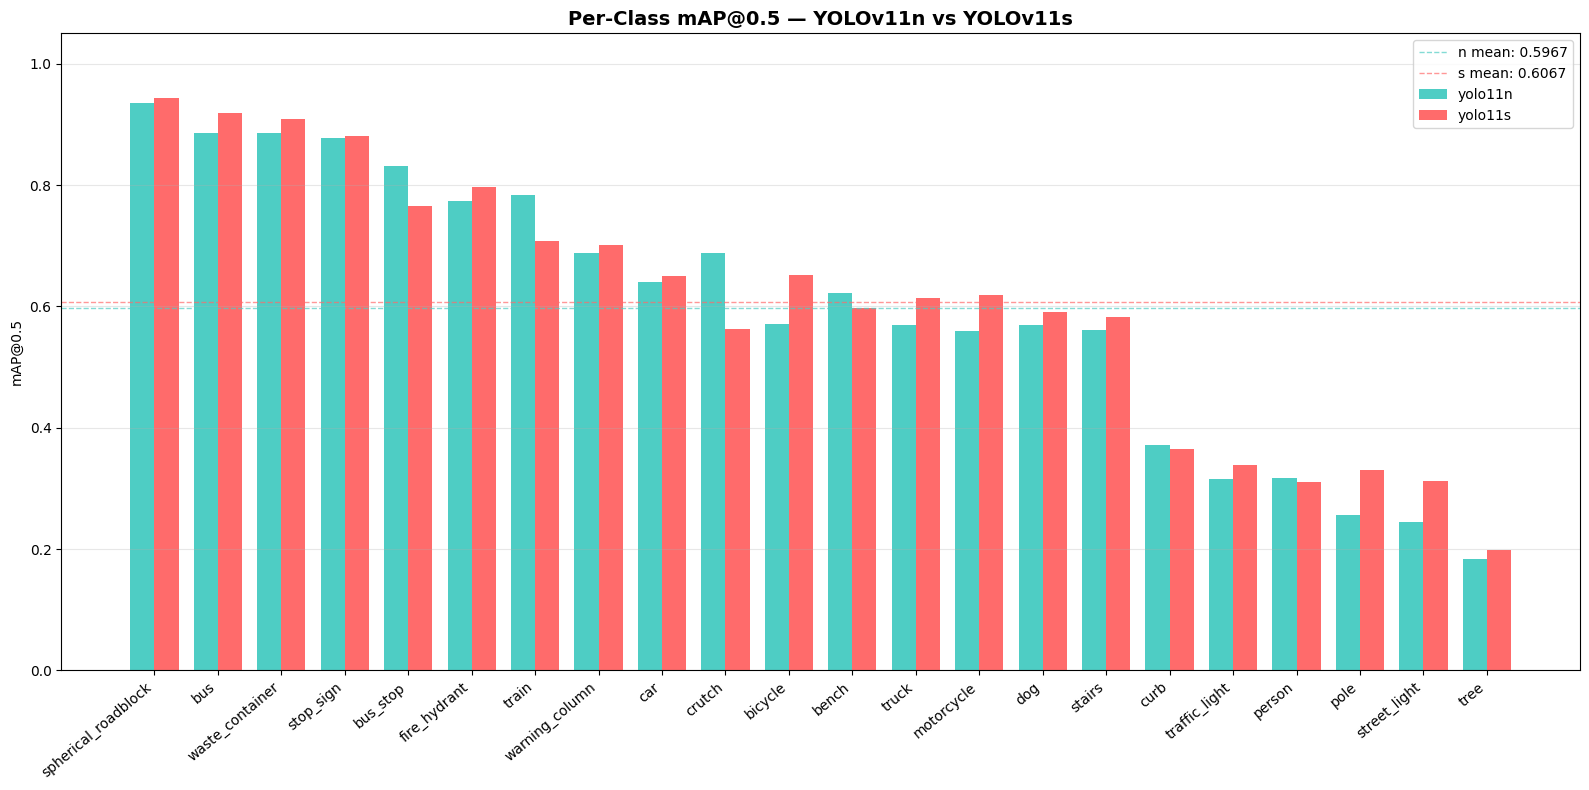


yolo11n mean mAP@0.5: 0.5967
yolo11s mean mAP@0.5: 0.6067


In [1]:
# ═══ PER-CLASS mAP@0.5 — YOLOv11n & YOLOv11s ═══
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from IPython.display import display

df_n = pd.read_csv("perclass_yolo11n.csv").set_index("class")
df_s = pd.read_csv("perclass_yolo11s.csv").set_index("class")
df_both = pd.DataFrame({"yolo11n": df_n["mAP50"], "yolo11s": df_s["mAP50"]})
df_both["mean"] = df_both.mean(axis=1)
df_both = df_both.sort_values("mean", ascending=False).drop(columns="mean")

print("Per-Class mAP@0.5 — YOLOv11n vs YOLOv11s")
print("=" * 55)
print(f"  {'Class':22s} {'yolo11n':>8} {'yolo11s':>8}")
print("-" * 42)
for cls, row in df_both.iterrows():
    winner = "<-- n" if row["yolo11n"] >= row["yolo11s"] else "      <-- s"
    print(f"  {cls:22s} {row['yolo11n']:8.4f} {row['yolo11s']:8.4f}  {winner}")

styled = (
    df_both.style
    .set_caption("Per-Class mAP@0.5 — YOLOv11n vs YOLOv11s")
    .format("{:.4f}")
    .background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1)
    .highlight_max(axis=1, color="#d4edda")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-size","14px"),("font-weight","bold"),("padding","8px")]},
        {"selector": "th",      "props": [("background-color","#1a1a2e"),("color","white"),("padding","8px")]},
        {"selector": "td",      "props": [("padding","6px 14px")]},
    ])
)
display(styled)

classes = df_both.index.tolist()
x = np.arange(len(classes))
width = 0.38
fig, ax = plt.subplots(figsize=(16, 8))
b1 = ax.bar(x - width/2, df_both["yolo11n"], width, label="yolo11n", color="#4ECDC4")
b2 = ax.bar(x + width/2, df_both["yolo11s"], width, label="yolo11s", color="#FF6B6B")
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=40, ha="right", fontsize=10)
ax.set_ylabel("mAP@0.5"); ax.set_ylim(0, 1.05)
ax.set_title("Per-Class mAP@0.5 — YOLOv11n vs YOLOv11s", fontsize=14, fontweight="bold")
ax.axhline(y=df_both["yolo11n"].mean(), color="#4ECDC4", linestyle="--", linewidth=1, alpha=0.7, label=f"n mean: {df_both['yolo11n'].mean():.4f}")
ax.axhline(y=df_both["yolo11s"].mean(), color="#FF6B6B", linestyle="--", linewidth=1, alpha=0.7, label=f"s mean: {df_both['yolo11s'].mean():.4f}")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("perclass_yolo11_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nyolo11n mean mAP@0.5: {df_both['yolo11n'].mean():.4f}")
print(f"yolo11s mean mAP@0.5: {df_both['yolo11s'].mean():.4f}")


In [1]:
# ═══ SAHI EVALUATION: Standard vs Sliced Inference — YOLOv11n & YOLOv11s ═══
try:
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "sahi", "-q"])
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image
from IPython.display import display

# ── Config ─────────────────────────────────────────────────────────────────
RUNS_BASE   = Path("../runs/detect")
TEST_IMGS   = Path("../dataset/test/images")
TEST_LBLS   = Path("../dataset/test/labels")
SLICE_H, SLICE_W = 512, 512
OVERLAP     = 0.2
CONF        = 0.25
IOU_THRESH  = 0.5
MAX_IMAGES  = 200  # use 200 test images for speed

CLASS_NAMES = [
    'bench','bicycle','bus','bus_stop','car','crutch','curb','dog',
    'fire_hydrant','motorcycle','person','pole','spherical_roadblock',
    'stairs','stop_sign','street_light','traffic_light','train',
    'tree','truck','warning_column','waste_container'
]
NC = len(CLASS_NAMES)
cls2idx = {c: i for i, c in enumerate(CLASS_NAMES)}

# ── Helpers ────────────────────────────────────────────────────────────────
def iou(b1, b2):
    x1, y1 = max(b1[0],b2[0]), max(b1[1],b2[1])
    x2, y2 = min(b1[2],b2[2]), min(b1[3],b2[3])
    inter = max(0,x2-x1)*max(0,y2-y1)
    a1 = (b1[2]-b1[0])*(b1[3]-b1[1])
    a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
    return inter/(a1+a2-inter+1e-9)

def load_gt(lbl_path, img_w, img_h):
    """Load YOLO format labels → list of (cls_idx, x1,y1,x2,y2)."""
    boxes = []
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        return boxes
    for line in lbl_path.read_text().strip().split('\n'):
        parts = line.strip().split()
        if len(parts) < 5: continue
        c, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x1 = (cx - bw/2) * img_w
        y1 = (cy - bh/2) * img_h
        x2 = (cx + bw/2) * img_w
        y2 = (cy + bh/2) * img_h
        boxes.append((c, x1, y1, x2, y2))
    return boxes

def preds_to_boxes(result):
    """Extract (cls_idx, conf, x1,y1,x2,y2) from ultralytics result."""
    boxes = []
    if result.boxes is None: return boxes
    for box in result.boxes:
        c  = int(box.cls.item())
        cf = float(box.conf.item())
        x1,y1,x2,y2 = box.xyxy[0].tolist()
        boxes.append((c, cf, x1, y1, x2, y2))
    return boxes

def sahi_to_boxes(sahi_result):
    """Extract (cls_idx, conf, x1,y1,x2,y2) from SAHI result."""
    boxes = []
    for obj in sahi_result.object_prediction_list:
        c  = obj.category.id
        cf = obj.score.value
        bb = obj.bbox
        boxes.append((c, cf, bb.minx, bb.miny, bb.maxx, bb.maxy))
    return boxes

def compute_ap(preds_all, gts_all, cls_idx):
    """Compute AP50 for a single class using all images."""
    detections = []  # (conf, tp)
    n_gt = 0
    for preds, gts in zip(preds_all, gts_all):
        gt_cls = [g for g in gts if g[0] == cls_idx]
        n_gt += len(gt_cls)
        pred_cls = sorted([p for p in preds if p[0] == cls_idx], key=lambda x: -x[1])
        matched = [False] * len(gt_cls)
        for p in pred_cls:
            best_iou, best_j = 0, -1
            for j, g in enumerate(gt_cls):
                if matched[j]: continue
                v = iou([p[2],p[3],p[4],p[5]], [g[1],g[2],g[3],g[4]])
                if v > best_iou:
                    best_iou, best_j = v, j
            tp = 0
            if best_iou >= IOU_THRESH and best_j >= 0:
                tp = 1
                matched[best_j] = True
            detections.append((p[1], tp))
    if n_gt == 0: return 0.0
    detections.sort(key=lambda x: -x[0])
    tp_cum, fp_cum = 0, 0
    prec, rec = [], []
    for _, tp in detections:
        if tp: tp_cum += 1
        else:  fp_cum += 1
        prec.append(tp_cum/(tp_cum+fp_cum))
        rec.append(tp_cum/n_gt)
    # Compute area under PR curve (11-point interpolation)
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        p = [prec[i] for i in range(len(rec)) if rec[i] >= t]
        ap += max(p) if p else 0.0
    return ap / 11.0

# ── Load test images ───────────────────────────────────────────────────────
img_paths = sorted([p for p in TEST_IMGS.glob('*.*') if p.suffix.lower() in {'.jpg','.jpeg','.png'}])[:MAX_IMAGES]
print(f"Using {len(img_paths)} test images for SAHI evaluation...")

# Pre-load GT
gts_all = []
for ip in img_paths:
    lp = (TEST_LBLS / ip.stem).with_suffix('.txt')
    img = Image.open(ip)
    gts_all.append(load_gt(lp, img.width, img.height))

# ── Evaluate both models ───────────────────────────────────────────────────
MODELS_TO_EVAL = {
    "yolo11n": RUNS_BASE / "yolo11n" / "weights" / "best.pt",
    "yolo11s": RUNS_BASE / "yolo11s" / "weights" / "best.pt",
}

results_rows = []

for model_name, weights_path in MODELS_TO_EVAL.items():
    if not weights_path.exists():
        print(f"SKIP {model_name}: no best.pt")
        continue
    print(f"\n{'='*55}")
    print(f"  Evaluating {model_name}")
    print(f"{'='*55}")

    # ── Standard inference ──────────────────────────────────────
    from ultralytics import YOLO
    import time
    yolo_model = YOLO(str(weights_path))
    std_preds_all = []
    t0 = time.perf_counter()
    for ip in img_paths:
        res = yolo_model(str(ip), conf=CONF, verbose=False, imgsz=832)
        std_preds_all.append(preds_to_boxes(res[0]))
    std_time = (time.perf_counter() - t0) / len(img_paths) * 1000
    print(f"  Standard: done ({std_time:.1f} ms/img)")

    # ── SAHI inference ──────────────────────────────────────────
    sahi_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=str(weights_path),
        confidence_threshold=CONF,
        device="cuda:0",
        category_mapping={str(i): n for i, n in enumerate(CLASS_NAMES)},
    )
    sahi_preds_all = []
    t0 = time.perf_counter()
    for ip in img_paths:
        res = get_sliced_prediction(
            str(ip), sahi_model,
            slice_height=SLICE_H, slice_width=SLICE_W,
            overlap_height_ratio=OVERLAP, overlap_width_ratio=OVERLAP,
            verbose=0,
        )
        sahi_preds_all.append(sahi_to_boxes(res))
    sahi_time = (time.perf_counter() - t0) / len(img_paths) * 1000
    print(f"  SAHI    : done ({sahi_time:.1f} ms/img)")

    # ── Compute per-class AP ─────────────────────────────────────
    std_ap_list, sahi_ap_list = [], []
    for cls_idx in range(NC):
        std_ap  = compute_ap(std_preds_all,  gts_all, cls_idx)
        sahi_ap = compute_ap(sahi_preds_all, gts_all, cls_idx)
        std_ap_list.append(round(std_ap, 4))
        sahi_ap_list.append(round(sahi_ap, 4))

    std_map  = round(np.mean(std_ap_list),  4)
    sahi_map = round(np.mean(sahi_ap_list), 4)
    gain     = round(sahi_map - std_map, 4)

    print(f"\n  mAP@0.5 Standard : {std_map:.4f}")
    print(f"  mAP@0.5 SAHI     : {sahi_map:.4f}  (gain: {gain:+.4f})")
    print(f"  Speed  Standard  : {std_time:.1f} ms/img")
    print(f"  Speed  SAHI      : {sahi_time:.1f} ms/img")

    results_rows.append({
        "Model": model_name,
        "mAP@0.5 Standard":  std_map,
        "mAP@0.5 SAHI":      sahi_map,
        "Gain":              gain,
        "Speed Std (ms)":    round(std_time, 1),
        "Speed SAHI (ms)":   round(sahi_time, 1),
    })

    # Per-class breakdown
    df_pc = pd.DataFrame({
        "Class":    CLASS_NAMES,
        "Standard": std_ap_list,
        "SAHI":     sahi_ap_list,
        "Delta":    [round(s-t,4) for s,t in zip(sahi_ap_list, std_ap_list)],
    }).sort_values("Delta", ascending=False).reset_index(drop=True)

    print(f"\n  Per-class gain (top 5 improved with SAHI):")
    print(f"  {'Class':22s} Std    SAHI   Delta")
    for _, row in df_pc.head(5).iterrows():
        print(f"  {row['Class']:22s} {row['Standard']:.4f} {row['SAHI']:.4f} {row['Delta']:+.4f}")

# ── Summary table ──────────────────────────────────────────────────────────
df_summary = pd.DataFrame(results_rows).set_index("Model")
print("\n\n" + "="*65)
print("  SAHI vs Standard — Summary")
print("="*65)
print(df_summary.to_string())

styled_summary = (
    df_summary.style
    .set_caption("YOLOv11 — Standard vs SAHI mAP@0.5 Comparison")
    .format({"mAP@0.5 Standard":"{:.4f}", "mAP@0.5 SAHI":"{:.4f}", "Gain":"{:+.4f}"})
    .highlight_max(subset=["mAP@0.5 Standard","mAP@0.5 SAHI"], color="#c6efce", axis=0)
    .applymap(lambda v: "background-color:#c6efce" if isinstance(v,float) and v>0 else
                        ("background-color:#ffc7ce" if isinstance(v,float) and v<0 else ""),
              subset=["Gain"])
    .set_properties(**{"text-align":"center","font-size":"13px"})
    .set_table_styles([
        {"selector":"caption","props":[("font-size","14px"),("font-weight","bold"),("padding","8px")]},
        {"selector":"th",     "props":[("background-color","#1a1a2e"),("color","white"),("padding","8px")]},
        {"selector":"td",     "props":[("padding","7px 14px")]},
    ])
)
display(styled_summary)

# ── Bar chart ──────────────────────────────────────────────────────────────
if len(results_rows) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("SAHI vs Standard Inference — YOLOv11 Benchmark", fontsize=14, fontweight="bold")

    models   = df_summary.index.tolist()
    x        = np.arange(len(models))
    width    = 0.35
    std_vals = df_summary["mAP@0.5 Standard"].values
    sahi_vals= df_summary["mAP@0.5 SAHI"].values

    b1 = axes[0].bar(x - width/2, std_vals,  width, label="Standard", color="#4ECDC4")
    b2 = axes[0].bar(x + width/2, sahi_vals, width, label="SAHI",     color="#FF6B6B")
    axes[0].set_xticks(x); axes[0].set_xticklabels(models)
    axes[0].set_ylim(0, 1); axes[0].set_ylabel("mAP@0.5")
    axes[0].set_title("mAP@0.5: Standard vs SAHI", fontweight="bold")
    axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)
    for b, v in zip(list(b1)+list(b2), list(std_vals)+list(sahi_vals)):
        axes[0].text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")

    std_spd  = df_summary["Speed Std (ms)"].values
    sahi_spd = df_summary["Speed SAHI (ms)"].values
    b3 = axes[1].bar(x - width/2, std_spd,  width, label="Standard", color="#45B7D1")
    b4 = axes[1].bar(x + width/2, sahi_spd, width, label="SAHI",     color="#A29BFE")
    axes[1].set_xticks(x); axes[1].set_xticklabels(models)
    axes[1].set_ylabel("ms / image"); axes[1].set_title("Inference Speed: Standard vs SAHI", fontweight="bold")
    axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
    for b, v in zip(list(b3)+list(b4), list(std_spd)+list(sahi_spd)):
        axes[1].text(b.get_x()+b.get_width()/2, v+1, f"{v:.0f}ms", ha="center", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.savefig("sahi_vs_standard_yolo11.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nSaved -> sahi_vs_standard_yolo11.png")


Using 200 test images for SAHI evaluation...



  Evaluating yolo11n


  Standard: done (215.5 ms/img)


  SAHI    : done (1230.7 ms/img)

  mAP@0.5 Standard : 0.0000
  mAP@0.5 SAHI     : 0.0000  (gain: +0.0000)
  Speed  Standard  : 215.5 ms/img
  Speed  SAHI      : 1230.7 ms/img

  Per-class gain (top 5 improved with SAHI):
  Class                  Std    SAHI   Delta
  bench                  0.0000 0.0000 +0.0000
  bicycle                0.0000 0.0000 +0.0000
  bus                    0.0000 0.0000 +0.0000
  bus_stop               0.0000 0.0000 +0.0000
  car                    0.0000 0.0000 +0.0000

  Evaluating yolo11s


  Standard: done (197.6 ms/img)


  SAHI    : done (1190.1 ms/img)

  mAP@0.5 Standard : 0.0000
  mAP@0.5 SAHI     : 0.0000  (gain: +0.0000)
  Speed  Standard  : 197.6 ms/img
  Speed  SAHI      : 1190.1 ms/img

  Per-class gain (top 5 improved with SAHI):
  Class                  Std    SAHI   Delta
  bench                  0.0000 0.0000 +0.0000
  bicycle                0.0000 0.0000 +0.0000
  bus                    0.0000 0.0000 +0.0000
  bus_stop               0.0000 0.0000 +0.0000
  car                    0.0000 0.0000 +0.0000


  SAHI vs Standard — Summary
         mAP@0.5 Standard  mAP@0.5 SAHI  Gain  Speed Std (ms)  Speed SAHI (ms)
Model                                                                         
yolo11n               0.0           0.0   0.0           215.5           1230.7
yolo11s               0.0           0.0   0.0           197.6           1190.1


C:\Users\admin\AppData\Local\Temp\ipykernel_17356\2799206717.py:232: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: "background-color:#c6efce" if isinstance(v,float) and v>0 else


,mAP@0.5 Standard,mAP@0.5 SAHI,Gain,Speed Std (ms),Speed SAHI (ms)
Model,,,,,
yolo11n,0.0000,0.0000,+0.0000,215.500000,1230.700000
yolo11s,0.0000,0.0000,+0.0000,197.600000,1190.100000
